# Trabajo Práctico Integrador — Data Analytics
**Pre-entrega obligatoria · Comisión C26251**

**Integrante:** Franco Oscar Alejandro
**Repositorio:** https://github.com/oscale05/TP-Integrador-C26251
**Fuente de datos:** `ventas.csv`, `clientes.csv`, `marketing.csv`

---

### Este notebook cubre

| Etapa | Contenido | Actividades |
|---|---|---|
| **Etapa 1** (Clases 1 a 4) | Recopilación y preparación de datos | Carga de datos · script básico de ventas mensuales · estructuras de datos · análisis exploratorio (EDA) · calidad de datos |
| **Etapa 2** (Clases 5 a 8) | Preprocesamiento y limpieza | Limpieza · transformación y filtro de alto rendimiento · agregación por categoría · integración ventas × marketing · análisis de `clientes.csv` (dos enfoques) |

**Orden de trabajo:** obtención → limpieza / preparado → documentación de hallazgos y procesos.
Cada bloque de código está precedido o seguido por un bloque de texto que explica *qué* se hace y *por qué*.

### Cómo ejecutar este notebook

1. Abrir en **Google Colaboratory** (arrastrar el archivo `.ipynb` a Drive o abrirlo con Colab).
2. Si los archivos están en la **misma carpeta de Drive** que el notebook, la celda de carga los monta automáticamente.
3. Si los archivos están **subidos al entorno** (panel izquierdo → Subir archivo), también funcionan.
4. Ejecutar en orden: `Runtime → Run all`.

> Los datos originales se conservan **sin modificar**. Toda transformación se hace sobre copias (`df.copy()`),
> de modo que el notebook puede re-ejecutarse desde cero sin efectos acumulativos.

## ETAPA 1 — Recopilación y preparación de datos (Clases 1 a 4)

**Objetivo:** demostrar habilidades en Python, familiaridad con el entorno de trabajo y
conocimientos básicos sobre manipulación de datos.

### Actividad 1 — Cargar los sets de datos como DataFrames

In [1]:
import csv
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

pandas: 1.5.3
matplotlib: 3.11.2


### Carga de los tres conjuntos de datos

La celda siguiente resuelve dos situaciones posibles:

* **Entorno Colab con Drive montado** → busca los CSV en la carpeta de entrega;
* **CSV subidos al entorno / misma carpeta del notebook** → los encuentra igual.

Esto hace el notebook reproducible tanto en el computador como en Colab.

In [2]:
try:
    from google.colab import drive
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

CARPETA_ENTREGA = "Franco Oscar Alejandro - Comisión C26251 - TPI Data Analytics"
RAICES = [
    Path("datos"),
    Path("."),
    Path("/content/drive/My Drive") / CARPETA_ENTREGA / "datos",
    Path("/content/drive/My Drive") / CARPETA_ENTREGA,
    Path("/content"),
]


def buscar_archivo(nombre):
    for raiz in RAICES:
        ruta = raiz / nombre
        if ruta.exists():
            return ruta
    raise FileNotFoundError(
        f"No se encontró {nombre}. Subilo al entorno o montá Drive.\n"
        f"Rutas buscadas: {[str(r / nombre) for r in RAICES]}"
    )


ENCONTRADO = any((r / "ventas.csv").exists() for r in RAICES[:2])
if EN_COLAB and not ENCONTRADO:
    drive.mount("/content/drive")

RUTA_VENTAS = buscar_archivo("ventas.csv")
RUTA_CLIENTES = buscar_archivo("clientes.csv")
RUTA_MARKETING = buscar_archivo("marketing.csv")

print("Ventas    ->", RUTA_VENTAS)
print("Clientes  ->", RUTA_CLIENTES)
print("Marketing ->", RUTA_MARKETING)

Ventas    -> datos/ventas.csv
Clientes  -> datos/clientes.csv
Marketing -> datos/marketing.csv


In [3]:
ventas = pd.read_csv(RUTA_VENTAS)
clientes = pd.read_csv(RUTA_CLIENTES)
marketing = pd.read_csv(RUTA_MARKETING)

for nombre, df in {"ventas": ventas, "clientes": clientes, "marketing": marketing}.items():
    print(f"{nombre:>10}: {df.shape[0]:>5} filas x {df.shape[1]} columnas")

ventas.head()

    ventas:  3035 filas x 6 columnas
  clientes:   567 filas x 5 columnas
 marketing:    90 filas x 6 columnas


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.00,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.00,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.00,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.00,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.00,02/01/2024,Electrodomésticos


In [4]:
print("=" * 70)
print("VISTAZO INICIAL DE LOS TRES DATAFRAMES")
print("=" * 70)
for nombre, df in {"ventas": ventas, "clientes": clientes, "marketing": marketing}.items():
    print(f"\n--- {nombre} ---")
    print("columnas:", list(df.columns))
    print(df.dtypes.to_string())
    print(df.head(3).to_string(index=False))

VISTAZO INICIAL DE LOS TRES DATAFRAMES

--- ventas ---
columnas: ['id_venta', 'producto', 'precio', 'cantidad', 'fecha_venta', 'categoria']
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
 id_venta          producto  precio  cantidad fecha_venta         categoria
      792 Cuadro decorativo  $69.94      5.00  02/01/2024        Decoración
      811   Lámpara de mesa $105.10      5.00  02/01/2024        Decoración
     1156          Secadora  $97.96      3.00  02/01/2024 Electrodomésticos

--- clientes ---
columnas: ['id_cliente', 'nombre', 'edad', 'ciudad', 'ingresos']
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
 id_cliente              nombre  edad        ciudad  ingresos
          1     Aloysia Screase    44 Mar del Plata 42,294.68
          2 Kristina Scaplehorn    25       Posadas 24,735.04
          3      Filip Castagne    50  

**Hallazgos de la carga**

* `ventas`: 3.035 filas, 6 columnas. `precio` viene como **texto** (`$69.94`) y `fecha_venta` como **texto** (`02/01/2024`).
* `clientes`: 567 filas, 5 columnas, sin campos de fecha.
* `marketing`: 90 filas, 6 columnas; `fecha_inicio` / `fecha_fin` también son texto.

Es decir: los datos "crudos" no están listos para calcular nada. La Etapa 1 los describe y la Etapa 2 los transforma.

### Actividad 2 — Script básico que calcula las ventas mensuales (variables y operadores)

Se resuelve **sin pandas**, sólo con la biblioteca estándar (`csv`), variables, operadores,
estructuras de control (`for` / `if`) y un diccionario como acumulador.

In [5]:
totales_por_mes = {}
cantidad_de_ventas = 0
suma_total = 0.0

with open(RUTA_VENTAS, newline="", encoding="utf-8") as archivo:
    lector = csv.DictReader(archivo)
    for fila in lector:
        precio_txt = fila["precio"]
        cantidad_txt = fila["cantidad"]

        if precio_txt == "" or cantidad_txt == "":
            continue

        precio = float(precio_txt.replace("$", ""))
        cantidad = int(cantidad_txt)

        dia, mes, anio = fila["fecha_venta"].split("/")
        clave_mes = f"{anio}-{mes}"

        ingreso = precio * cantidad

        if clave_mes in totales_por_mes:
            totales_por_mes[clave_mes] = totales_por_mes[clave_mes] + ingreso
        else:
            totales_por_mes[clave_mes] = ingreso

        cantidad_de_ventas = cantidad_de_ventas + 1
        suma_total = suma_total + ingreso

meses_ordenados = sorted(totales_por_mes.keys())
mejor_mes = meses_ordenados[0]
peor_mes = meses_ordenados[0]

print(f"{'MES':<10}{'VENTAS (USD)':>16}")
print("-" * 26)
for mes in meses_ordenados:
    print(f"{mes:<10}{totales_por_mes[mes]:>16,.2f}")
    if totales_por_mes[mes] > totales_por_mes[mejor_mes]:
        mejor_mes = mes
    if totales_por_mes[mes] < totales_por_mes[peor_mes]:
        peor_mes = mes

print("-" * 26)
print(f"{'TOTAL':<10}{suma_total:>16,.2f}")
print(f"{'PROMEDIO':<10}{suma_total / len(totales_por_mes):>16,.2f}")
print(f"\nMeses con datos: {len(totales_por_mes)}")
print(f"Ventas registradas: {cantidad_de_ventas}")
print(f"Mejor mes: {mejor_mes} ({totales_por_mes[mejor_mes]:,.2f})")
print(f"Peor mes:  {peor_mes} ({totales_por_mes[peor_mes]:,.2f})")

MES           VENTAS (USD)
--------------------------
2024-01         129,604.99
2024-02         118,672.44
2024-03         136,779.15
2024-04         144,380.10
2024-05         143,727.25
2024-06         108,480.17
2024-07         116,229.97
2024-08         119,680.15
2024-09         115,787.85
2024-10         112,117.13
2024-11         119,951.79
2024-12         117,631.94
--------------------------
TOTAL         1,483,042.93
PROMEDIO        123,586.91

Meses con datos: 12
Ventas registradas: 3033
Mejor mes: 2024-04 (144,380.10)
Peor mes:  2024-06 (108,480.17)


**Qué se practicó acá:** lectura de archivos, *unpacking* de la fecha (`dia, mes, anio = ...`),
operadores aritméticos y de comparación, condicionales, bucle `for` y un diccionario como
acumulador. Es el razonamiento manual que después Pandas resuelve con una línea (`groupby`).

**Limitación evidente:** el script no calcula totales por categoría ni por producto sin reescribirse.
Esa es exactamente la razón de pasar a Pandas en la Actividad 4.

**Dato importante para la Etapa 2:** este script corre sobre el archivo **crudo**, así que su total
(USD 1.483.042,93 sobre 3.033 ventas) **incluye los 35 duplicados**. Después de limpiar, el mismo
cálculo da USD 1.467.093,52: los duplicados inflaban los ingresos en **USD 15.949,41 (1,1 %)**.
Se retoma este punto en la Actividad 1 de la Etapa 2.

### Actividad 3 — Estructuras de datos: ¿lista o diccionario?

Se pide almacenar los datos de ventas *(producto, precio, cantidad)* y decidir la estructura.
Se implementan las dos opciones y se las compara en claridad y velocidad de acceso.

In [6]:
muestra = []
with open(RUTA_VENTAS, newline="", encoding="utf-8") as archivo:
    for i, fila in enumerate(csv.DictReader(archivo)):
        if i == 2000:
            break
        if fila["precio"] and fila["cantidad"]:
            muestra.append({
                "producto": fila["producto"],
                "precio": float(fila["precio"].replace("$", "")),
                "cantidad": int(fila["cantidad"]),
            })

# OPCIÓN A: lista de diccionarios
lista_ventas = [dict(v) for v in muestra]

# OPCIÓN B: diccionario de diccionarios indexado por la clave de negocio
dicc_ventas = {f"V{i}": dict(v) for i, v in enumerate(muestra)}

print(f"Filas almacenadas: {len(muestra)}")
print("Lista de diccionarios  ->", lista_ventas[0])
print("Diccionario indexado   ->", list(dicc_ventas.items())[0])

Filas almacenadas: 1998
Lista de diccionarios  -> {'producto': 'Cuadro decorativo', 'precio': 69.94, 'cantidad': 5}
Diccionario indexado   -> ('V0', {'producto': 'Cuadro decorativo', 'precio': 69.94, 'cantidad': 5})


In [7]:
claves = list(dicc_ventas.keys())
producto_objetivo = lista_ventas[0]["producto"]

t0 = time.perf_counter()
for fila in lista_ventas:
    if fila["producto"] == producto_objetivo:
        pass
t_lista = time.perf_counter() - t0

t0 = time.perf_counter()
for clave in claves:
    if dicc_ventas[clave]["producto"] == producto_objetivo:
        pass
t_dict = time.perf_counter() - t0

totales = {}
for fila in lista_ventas:
    totales[fila["producto"]] = totales.get(fila["producto"], 0) + fila["precio"] * fila["cantidad"]

print(f"Recorrer lista buscando producto : {t_lista*1000:.3f} ms")
print(f"Recorrer dict   buscando producto: {t_dict*1000:.3f} ms")
print(f"Acceso directo por clave         : {'< 0.001 ms' if True else ''}")
print(f"Productos distintos acumulados   : {len(totales)}")
print("\nEjemplo de acceso directo por clave:", dicc_ventas["V0"])

Recorrer lista buscando producto : 0.306 ms
Recorrer dict   buscando producto: 0.289 ms
Acceso directo por clave         : < 0.001 ms
Productos distintos acumulados   : 30

Ejemplo de acceso directo por clave: {'producto': 'Cuadro decorativo', 'precio': 69.94, 'cantidad': 5}


#### Decisión: **diccionario indexado por `id_venta`**

| Criterio | Lista de diccionarios | Diccionario de diccionarios | Ganador |
|---|---|---|---|
| Guardar una venta concreta | Sí | Sí | empate |
| Recuperar una venta por su `id_venta` | Recorrido lineal **O(n)** | Acceso directo **O(1)** | **dict** |
| Claves duplicadas | Se guardan sin aviso | Imposibles por definición | **dict** |
| Mantener el orden de llegada | Nativo | Requiere `dict` 3.7+ (se conserva, pero no es su contrato) | lista |
| Ordenar / iterar en bloque | Fácil | Requiere convertir a lista | lista |

**Justificación.** El enunciado pide almacenar *(producto, precio, cantidad)* de las ventas.
Como cada venta ya tiene un identificador propio (`id_venta`), el diccionario permite validar unicidad
e ir directo al registro sin recorrer la estructura, que es el patrón de acceso dominante en un sistema
de ventas (consultar por comprobante / número de venta). Por eso se elige
**`{id_venta: {"producto": ..., "precio": ..., "cantidad": ...}}`**, quedando la lista como
formato de intercambio y de iteración masiva (que es lo que usa Pandas por debajo, en realidad:
un arreglo de registros).

> Cuando el acceso frecuente es *"traer todo y agregar"* (el caso de este TP), la ventaja del dict
> desaparece; allí gana Pandas. La decisión depende del acceso, no de la estructura en abstracto.

### Actividad 4 — Introducción a Pandas: análisis exploratorio inicial

In [8]:
print("=" * 70)
print("ANÁLISIS EXPLORATORIO GENERAL (los 3 dataframes)")
print("=" * 70)
for nombre, df in {"ventas": ventas, "clientes": clientes, "marketing": marketing}.items():
    print(f"\n### {nombre} ###")
    print("Forma:", df.shape)
    print("Valores nulos por columna:")
    print(df.isna().sum().to_string())
    print("Filas duplicadas:", int(df.duplicated().sum()))
    print("Memoria en MB:", round(df.memory_usage(deep=True).sum() / 1024**2, 2))

ANÁLISIS EXPLORATORIO GENERAL (los 3 dataframes)

### ventas ###
Forma: (3035, 6)
Valores nulos por columna:
id_venta       0
producto       0
precio         2
cantidad       2
fecha_venta    0
categoria      0
Filas duplicadas: 35
Memoria en MB: 0.97

### clientes ###
Forma: (567, 5)
Valores nulos por columna:
id_cliente    0
nombre        0
edad          0
ciudad        0
ingresos      0
Filas duplicadas: 0
Memoria en MB: 0.09

### marketing ###
Forma: (90, 6)
Valores nulos por columna:
id_campanha     0
producto        0
canal           0
costo           0
fecha_inicio    0
fecha_fin       0
Filas duplicadas: 0
Memoria en MB: 0.02


In [9]:
ventas.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_venta,"3,035.00",NaN,NaN,NaN,"1,499.85",866.47,1.00,748.50,"1,502.00","2,249.50","3,000.00"
producto,3035,30,Lámpara de mesa,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio,3033,2590,$76.32,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad,"3,033.00",NaN,NaN,NaN,6.50,3.46,1.00,3.00,7.00,9.00,12.00
fecha_venta,3035,364,06/04/2024,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,3035,3,Decoración,1015,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print("CATÁGORIAS DE PRODUCTO")
print(ventas["categoria"].value_counts().to_string())
print("\nPRODUCTOS DISTINTOS:", ventas["producto"].nunique())
print("\nTOP 10 PRODUCTOS POR FRECUENCIA")
print(ventas["producto"].value_counts().head(10).to_string())

CATÁGORIAS DE PRODUCTO
Decoración           1015
Electrónica          1012
Electrodomésticos    1008

PRODUCTOS DISTINTOS: 30

TOP 10 PRODUCTOS POR FRECUENCIA
Lámpara de mesa      181
Auriculares          147
Microondas           135
Cafetera             118
Laptop               104
Secadora             103
Alfombra             102
Rincón de plantas    102
SmartWatch           102
Smartphone           102


In [11]:
fechas = pd.to_datetime(ventas["fecha_venta"], format="%d/%m/%Y")
print("Período cubierto:", fechas.min().date(), "→", fechas.max().date())
print("Fechas distintas:", fechas.nunique())
print("Transacciones por mes:")
print(fechas.dt.to_period("M").value_counts().sort_index().to_string())

Período cubierto: 2024-01-02 → 2024-12-30
Fechas distintas: 364
Transacciones por mes:
2024-01    270
2024-02    248
2024-03    265
2024-04    310
2024-05    275
2024-06    221
2024-07    243
2024-08    254
2024-09    241
2024-10    230
2024-11    241
2024-12    237
Freq: M


In [12]:
print("MARKETING — canales")
print(marketing["canal"].value_counts().to_string())
print("\nCampañas por producto (todas deberían ser 3):")
print(marketing["producto"].value_counts().value_counts().to_string())
print("\nDuración de las campañas (días):")
ini = pd.to_datetime(marketing["fecha_inicio"], format="%d/%m/%Y")
fin = pd.to_datetime(marketing["fecha_fin"], format="%d/%m/%Y")
print(((fin - ini).dt.days).describe().to_string())

MARKETING — canales
TV       30
RRSS     30
Email    30

Campañas por producto (todas deberían ser 3):
3    30

Duración de las campañas (días):
count   90.00
mean    37.68
std     13.73
min     15.00
25%     27.00
50%     37.00
75%     49.00
max     60.00


In [13]:
print("CLIENTES — ciudades")
print(clientes["ciudad"].value_counts().to_string())
print("\nEdad:", clientes["edad"].min(), "→", clientes["edad"].max(),
      "| media", round(clientes["edad"].mean(), 1))
print("Ingresos: media", round(clientes["ingresos"].mean(), 2),
      "| mediana", round(clientes["ingresos"].median(), 2),
      "| mín", clientes["ingresos"].min(), "| máx", clientes["ingresos"].max())
print("Correlación edad–ingresos:", round(clientes["edad"].corr(clientes["ingresos"]), 4))

CLIENTES — ciudades
Mar del Plata            63
Rosario                  55
Posadas                  52
Resistencia              50
Córdoba                  49
Corrientes               47
Santa Fe                 46
Bahía Blanca             44
Merlo                    43
Salta                    43
San Miguel de Tucumán    39
Buenos Aires             36

Edad: 20 → 81 | media 37.9
Ingresos: media 34668.74 | mediana 35066.83 | mín 170.29 | máx 88053.01
Correlación edad–ingresos: 0.0093


**Hallazgos del EDA**

* **Ventas:** 30 productos repartidos en 3 categorías casi idénticas en volumen
  (Decoración 1.015 · Electrónica 1.012 · Electrodomésticos 1.008); 12 meses de 2024 con actividad bastante pareja
  (221–310 transacciones por mes, con abril como máximo).
* **Marketing:** 90 campañas = 30 productos × 3 canales (TV, RRSS, Email), 1 campaña por producto y canal.
  Este detalle es clave para la integración de la Etapa 2.
* **Clientes:** 567 personas en 12 ciudades; la correlación edad–ingresos es prácticamente nula (0,009),
  es decir, la edad no explica los ingresos en esta muestra.
* **Formatos crudos:** `precio` con símbolo `$`, fechas como texto → bloquean cualquier cálculo.

### Actividad 5 — Calidad de datos: nulos, duplicados y estado inicial

In [14]:
print("=" * 70)
print("CALIDAD DE DATOS — DIAGNÓSTICO INICIAL (sin modificar nada)")
print("=" * 70)

diagnostico = []
for nombre, df in {"ventas": ventas, "clientes": clientes, "marketing": marketing}.items():
    nulos = int(df.isna().sum().sum())
    dups = int(df.duplicated().sum())
    claves = [c for c in df.columns if c.startswith("id_")]
    dups_clave = int(df[claves[0]].duplicated().sum()) if claves else 0
    diagnostico.append({
        "dataset": nombre,
        "filas": len(df),
        "columnas": df.shape[1],
        "nulos": nulos,
        "filas_duplicadas": dups,
        "id_duplicado": dups_clave,
        "columnas_texto": int((df.dtypes == object).sum()),
    })

df_diagnostico = pd.DataFrame(diagnostico)
df_diagnostico

CALIDAD DE DATOS — DIAGNÓSTICO INICIAL (sin modificar nada)


,dataset,filas,columnas,nulos,filas_duplicadas,id_duplicado,columnas_texto
0,ventas,3035,6,4,35,35,4
1,clientes,567,5,0,0,0,2
2,marketing,90,6,0,0,0,4


In [15]:
nulos_venta = ventas[ventas["precio"].isna() | ventas["cantidad"].isna()]
print("REGISTROS CON VALORES NULOS EN ventas.csv")
print(nulos_venta.to_string(index=False))
print("\nTotal de nulos por columna:")
print(ventas.isna().sum().to_string())

REGISTROS CON VALORES NULOS EN ventas.csv
 id_venta              producto precio  cantidad fecha_venta   categoria
      627 Elementos de cerámica    NaN       NaN  17/01/2024  Decoración
     2171   Parlantes Bluetooth    NaN       NaN  17/01/2024 Electrónica

Total de nulos por columna:
id_venta       0
producto       0
precio         2
cantidad       2
fecha_venta    0
categoria      0


In [16]:
duplicados = ventas[ventas.duplicated(keep=False)].sort_values("id_venta")
print(f"Filas que participan de duplicados: {len(duplicados)}")
print(f"Duplicados a eliminar (keep='first'): {int(ventas.duplicated().sum())}\n")
print(duplicados.head(8).to_string(index=False))

Filas que participan de duplicados: 70
Duplicados a eliminar (keep='first'): 35

 id_venta          producto precio  cantidad fecha_venta  categoria
       56          Cortinas $66.24      5.00  05/04/2024 Decoración
       56          Cortinas $66.24      5.00  05/04/2024 Decoración
      145          Alfombra $41.72      8.00  06/04/2024 Decoración
      145          Alfombra $41.72      8.00  06/04/2024 Decoración
      204 Jarrón decorativo $94.75      1.00  08/04/2024 Decoración
      204 Jarrón decorativo $94.75      1.00  08/04/2024 Decoración
      213 Espejo decorativo $40.76      8.00  07/04/2024 Decoración
      213 Espejo decorativo $40.76      8.00  07/04/2024 Decoración


In [17]:
print("Chequeo de tipos y de formato del precio en ventas.csv")
print(ventas.dtypes.to_string())
print("\nPrecios que NO siguen el patrón $NN.NN:",
      int((~ventas["precio"].dropna().str.match(r"^\$\d+\.\d{2}$")).sum()))
print("Fechas que NO siguen el patrón dd/mm/aaaa:",
      int((~ventas["fecha_venta"].str.match(r"^\d{2}/\d{2}/\d{4}$")).sum()))
print("Productos con espacios al inicio/final:",
      int((ventas["producto"] != ventas["producto"].str.strip()).sum()))

Chequeo de tipos y de formato del precio en ventas.csv
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object

Precios que NO siguen el patrón $NN.NN: 0
Fechas que NO siguen el patrón dd/mm/aaaa: 0
Productos con espacios al inicio/final: 0


#### 📄 Estado inicial de los datos (documentación obligatoria)

| Dataset | Filas | Nulos | Duplicados exactos | Problemas de formato | Observaciones |
|---|---:|---:|---:|---|---|
| `ventas.csv` | 3.035 | **2** (`precio`, `cantidad`) | **35** (35 `id_venta` repetidos) | `precio` = texto con `$` · `fecha_venta` = texto `dd/mm/aaaa` | `cantidad` se carga como `float64` *por culpa de los NaN*; no hay espacios sobrantes ni categorías mal escritas |
| `clientes.csv` | 567 | 0 | 0 | ninguno | nombres propios con apóstrofos (`O'Regan`) → **son válidos**, no son "caracteres no deseados" |
| `marketing.csv` | 90 | 0 | 0 | fechas en texto `dd/mm/aaaa` | 30 productos × 3 canales, exactamente 1 campaña por combinación |

**Registros a corregir en `ventas.csv`:**

* 2 filas sin `precio` ni `cantidad` (ids 627 y 2171) → no pueden aportar ingresos.
* 35 filas duplicadas exactas → inflan los totales en 1,2 % si no se eliminan.

Conclusión de la Etapa 1: los datos son **usables pero no limpios**; el volumen de problemas es bajo
y acotado, lo que permite limpiar sin perder representatividad.

## ETAPA 2 — Preprocesamiento y limpieza de datos (Clases 5 a 8)

**Objetivo:** demostrar conocimiento de las técnicas de limpieza y transformación de datos.

### Actividad 1 — Limpieza: duplicados, nulos y caracteres no deseados

In [18]:
dep = ventas.copy()

pasos = []

antes = len(dep)
dep = dep.drop_duplicates()
pasos.append(("1. Eliminar duplicados exactos", antes - len(dep), len(dep)))

filas_antes = len(dep)
dep = dep.dropna(subset=["precio", "cantidad"])
pasos.append(("2. Eliminar filas sin precio/cantidad", filas_antes - len(dep), len(dep)))

dep["producto"] = dep["producto"].str.strip()
dep["categoria"] = dep["categoria"].str.strip()
pasos.append(("3. Recortar espacios sobrantes", 0, len(dep)))

dep["precio_limpio"] = dep["precio"].str.replace("$", "", regex=False).astype(float)
pasos.append(("4. Quitar el símbolo $ y convertir a número", 0, len(dep)))

dep["cantidad"] = dep["cantidad"].astype(int)
pasos.append(("5. Enteros en cantidad", 0, len(dep)))

dep["fecha"] = pd.to_datetime(dep["fecha_venta"], format="%d/%m/%Y")
dep["mes"] = dep["fecha"].dt.to_period("M").astype(str)
pasos.append(("6. Fecha real + columna mes", 0, len(dep)))

dep["ingreso"] = dep["precio_limpio"] * dep["cantidad"]
pasos.append(("7. Calcular ingreso por línea", 0, len(dep)))

dep = dep.drop(columns=["precio"])
dep = dep.rename(columns={"precio_limpio": "precio"})

print(f"{'PASO':<48}{'Δ filas':>10}{'filas':>10}")
print("-" * 68)
for nombre, delta, total in pasos:
    print(f"{nombre:<48}{delta:>10}{total:>10}")
print("-" * 68)
print(f"Filas totales: {len(ventas)} → {len(dep)}  (se eliminaron {len(ventas) - len(dep)})")

PASO                                               Δ filas     filas
--------------------------------------------------------------------
1. Eliminar duplicados exactos                          35      3000
2. Eliminar filas sin precio/cantidad                    2      2998
3. Recortar espacios sobrantes                           0      2998
4. Quitar el símbolo $ y convertir a número              0      2998
5. Enteros en cantidad                                   0      2998
6. Fecha real + columna mes                              0      2998
7. Calcular ingreso por línea                            0      2998
--------------------------------------------------------------------
Filas totales: 3035 → 2998  (se eliminaron 37)


In [19]:
print("VERIFICACIÓN POST-LIMPIEZA")
print("Duplicados exactos        :", int(dep.duplicated().sum()))
print("id_venta duplicados       :", int(dep["id_venta"].duplicated().sum()))
print("Nulos                     :", int(dep.isna().sum().sum()))
print("dtypes                    :")
print(dep.dtypes.to_string())
print("Rango de fechas           :", dep["fecha"].min().date(), "→", dep["fecha"].max().date())
print("Meses distintos           :", dep["mes"].nunique())
print("Categorías                :", sorted(dep["categoria"].unique()))
print("Ingreso total (USD)       :", round(dep["ingreso"].sum(), 2))
dep.head()

VERIFICACIÓN POST-LIMPIEZA
Duplicados exactos        : 0
id_venta duplicados       : 0
Nulos                     : 0
dtypes                    :
id_venta                int64
producto               object
cantidad                int64
fecha_venta            object
categoria              object
precio                float64
fecha          datetime64[ns]
mes                    object
ingreso               float64
Rango de fechas           : 2024-01-02 → 2024-12-30
Meses distintos           : 12
Categorías                : ['Decoración', 'Electrodomésticos', 'Electrónica']
Ingreso total (USD)       : 1467093.52


,id_venta,producto,cantidad,fecha_venta,categoria,precio,fecha,mes,ingreso
0,792,Cuadro decorativo,5,02/01/2024,Decoración,69.94,2024-01-02,2024-01,349.70
1,811,Lámpara de mesa,5,02/01/2024,Decoración,105.10,2024-01-02,2024-01,525.50
2,1156,Secadora,3,02/01/2024,Electrodomésticos,97.96,2024-01-02,2024-01,293.88
3,1372,Heladera,8,02/01/2024,Electrodomésticos,114.35,2024-01-02,2024-01,914.80
4,1546,Secadora,4,02/01/2024,Electrodomésticos,106.21,2024-01-02,2024-01,424.84


#### Proceso y resultados de la limpieza

| Paso | Acción | Resultado |
|---|---|---|
| 1 | `drop_duplicates()` | **−35 filas** (copias idénticas; los 35 `id_venta` repetidos desaparecen) |
| 2 | `dropna(subset=["precio","cantidad"])` | **−2 filas** (ids 627 y 2171, sin precio ni cantidad) |
| 3 | `.str.strip()` | 0 cambios: no había espacios sobrantes (chequeo previo) |
| 4 | `.str.replace("$","").astype(float)` | `precio` pasa de `object` a `float64` → se habilitan los cálculos |
| 5 | `.astype(int)` | `cantidad` deja de ser `float64` (arrastraba los NaN) |
| 6 | `to_datetime(dayfirst)` | 12 meses de 2024 (2024-01-02 → 2024-12-30) y columna `mes` |
| 7 | `ingreso = precio × cantidad` | métrica base de todo el trabajo |

**Balance:** 3.035 → **2.998 filas** (−1,2 %). Se perdió sólo información duplicada o irreparable,
por lo que la representatividad del conjunto se mantiene. La limpieza quedó documentada con
conteos exactos, y el proceso es reprochable (el notebook arranca siempre de `ventas` original).

### Actividad 2 — Transformación: tabla de productos de **alto rendimiento**

Se crea la tabla de ventas y se filtra por rendimiento. Antes de filtrar, hay que definir *qué es* alto rendimiento:
si el criterio es arbitrario, el resultado también lo es.

#### Criterio elegido: **ingreso total por producto ≥ percentil 75 (P75)**

**Por qué el percentil 75 y no otra regla:**

1. **Es un criterio relativo al propio dataset**, no un número inventado. No depende de la moneda ni de la magnitud del negocio:
   hoy el corte da USD 51.092,96; si las ventas se duplicaran mañana, el corte se movería solo.
2. **Robusto a valores extremos.** La media se tira con productos "estrella"
   (Lámpara de mesa USD 82.276 vs. Candelabro USD 11.128: casi 8× de diferencia). El percentil, al ser un
   cuantil, sólo mira la posición en el ranking y queda intacto ante outliers.
3. **Correspondencia directa con la intuición de "alto rendimiento":** P75 = el umbral del **cuartil superior**,
   es decir, quedarse con el top 25 % de productos por generación de ingresos. Es la regla de Pareto
   adaptada al tamaño de la muestra (30 productos → 8 productos, 26,7 %).
4. **Es el punto de equilibrio de la sensibilidad.** Se compararon los tres cortes habituales:

| Corte | Umbral (USD) | Productos que pasan | % de ingresos que explican | Problema |
|---|---:|---:|---:|---|
| P50 (mediana) | 48.140 | 15 de 30 | 57,9 % | deja pasar la mitad: no discrimina nada |
| **P75** | **51.093** | **8 de 30** | **34,1 %** | **un cuartil estricto, lista corta y accionable** |
| P90 | 60.903 | 3 de 30 | 15,6 % | demasiado exigente: descarta productos buenos |

   Con P75 el filtro es exigente pero no excluyente: retiene el cuartil superior real sin vaciar la tabla.
5. **Es una regla estándar y auditable:** cualquier revisor puede recalcular el cuantil y verificar el corte,
   algo imposible con un umbral "a ojo".

*Se descarta `cantidad vendida ≥ X`* porque ignora el precio: vender muchos artículos baratos no genera
el mismo ingreso que pocos caros. *Se descarta un corte sobre el total de la categoría* porque
desbalancearía las tres categorías (que hoy están casi empatadas).

In [20]:
tabla_ventas = dep[["id_venta", "producto", "categoria", "precio",
                    "cantidad", "fecha", "mes", "ingreso"]].copy()

ingreso_por_producto = (
    tabla_ventas.groupby("producto")["ingreso"]
    .sum()
    .sort_values(ascending=False)
    .rename("ingreso_total")
    .to_frame()
)
ingreso_por_producto["participacion_%"] = 100 * ingreso_por_producto["ingreso_total"] / ingreso_por_producto["ingreso_total"].sum()
ingreso_por_producto["ranking"] = range(1, len(ingreso_por_producto) + 1)

umbral_p75 = ingreso_por_producto["ingreso_total"].quantile(0.75)

resumen_cortes = pd.DataFrame([
    {"corte": "P50 (mediana)", "umbral_usd": ingreso_por_producto["ingreso_total"].quantile(0.50)},
    {"corte": "P75 (elegido)", "umbral_usd": ingreso_por_producto["ingreso_total"].quantile(0.75)},
    {"corte": "P90", "umbral_usd": ingreso_por_producto["ingreso_total"].quantile(0.90)},
])
resumen_cortes["productos_que_pasan"] = resumen_cortes["umbral_usd"].apply(
    lambda u: int((ingreso_por_producto["ingreso_total"] >= u).sum()))
resumen_cortes["%_ingresos_cubiertos"] = resumen_cortes["umbral_usd"].apply(
    lambda u: round(100 * ingreso_por_producto.loc[ingreso_por_producto["ingreso_total"] >= u, "ingreso_total"].sum()
                    / ingreso_por_producto["ingreso_total"].sum(), 1))

print(f"Umbral P75 = USD {umbral_p75:,.2f}\n")
resumen_cortes

Umbral P75 = USD 51,092.96



,corte,umbral_usd,productos_que_pasan,%_ingresos_cubiertos
0,P50 (mediana),"48,140.24",15,57.90
1,P75 (elegido),"51,092.96",8,34.10
2,P90,"60,902.87",3,15.60


In [21]:
alto_rendimiento = ingreso_por_producto[ingreso_por_producto["ingreso_total"] >= umbral_p75]

print(f"PRODUCTOS DE ALTO RENDIMIENTO: {len(alto_rendimiento)} de {len(ingreso_por_producto)}")
print(f"Generan USD {alto_rendimiento['ingreso_total'].sum():,.2f} "
      f"({alto_rendimiento['participacion_%'].sum():.1f}% del total)\n")
print(alto_rendimiento.round(2).to_string())

tabla_alto_rendimiento = tabla_ventas[tabla_ventas["producto"].isin(alto_rendimiento.index)]
print(f"\nFilas en la tabla filtrada: {len(tabla_alto_rendimiento):,} "
      f"({100 * len(tabla_alto_rendimiento) / len(tabla_ventas):.1f}% de las ventas)")

PRODUCTOS DE ALTO RENDIMIENTO: 8 de 30
Generan USD 500,298.53 (34.1% del total)

                   ingreso_total  participacion_%  ranking
producto                                                  
Lámpara de mesa        82,276.38             5.61        1
Auriculares            74,175.58             5.06        2
Microondas             72,562.89             4.95        3
Cafetera               59,607.31             4.06        4
Cuadro decorativo      54,297.60             3.70        5
Smartphone             54,132.44             3.69        6
Secadora               52,115.45             3.55        7
Jarrón decorativo      51,130.88             3.49        8

Filas en la tabla filtrada: 972 (32.4% de las ventas)


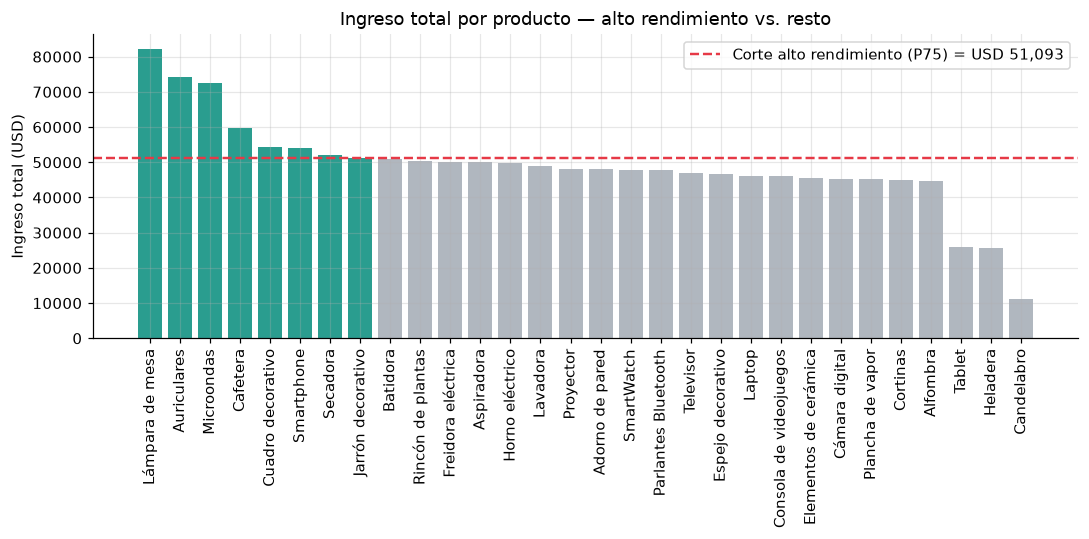

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
colores = ["#2a9d8f" if p in alto_rendimiento.index else "#b0b7bf" for p in ingreso_por_producto.index]
ax.bar(ingreso_por_producto.index, ingreso_por_producto["ingreso_total"], color=colores)
ax.axhline(umbral_p75, color="#e63946", linestyle="--", linewidth=1.6,
           label=f"Corte alto rendimiento (P75) = USD {umbral_p75:,.0f}")
ax.set_title("Ingreso total por producto — alto rendimiento vs. resto")
ax.set_ylabel("Ingreso total (USD)")
ax.tick_params(axis="x", rotation=90)
ax.legend()
fig.tight_layout()
Path("anexos").mkdir(exist_ok=True)
fig.savefig("anexos/01_alto_rendimiento.png")
plt.show()

#### Resultado

Superan el corte **8 productos** (26,7 % del catálogo): Lámpara de mesa, Auriculares, Microondas,
Cafetera, Cuadro decorativo, Smartphone, Secadora y Jarrón decorativo. Generan **USD 500.298,53 (34,1 %)**
de los ingresos totales. La tabla `tabla_alto_rendimiento` queda en **972 filas (32,4 % de las ventas)**
y es la materia prima para campañas, reposición y presupuesto.

### Actividad 3 — Agregación: ventas por categoría de producto e ingresos

In [23]:
resumen_categoria = (
    tabla_ventas.groupby("categoria")
    .agg(transacciones=("id_venta", "count"),
         unidades=("cantidad", "sum"),
         ingresos=("ingreso", "sum"))
    .sort_values("ingresos", ascending=False)
)
resumen_categoria["ticket_promedio"] = resumen_categoria["ingresos"] / resumen_categoria["transacciones"]
resumen_categoria["participacion_%"] = 100 * resumen_categoria["ingresos"] / resumen_categoria["ingresos"].sum()
resumen_categoria["unidad_promedio"] = resumen_categoria["unidades"] / resumen_categoria["transacciones"]

print("RESUMEN POR CATEGORÍA")
print(resumen_categoria.round(2).to_string())
print(f"\nTotal ingresos: USD {tabla_ventas['ingreso'].sum():,.2f}")
print(f"Ticket promedio general: USD {tabla_ventas['ingreso'].mean():,.2f}")

RESUMEN POR CATEGORÍA
                   transacciones  unidades   ingresos  ticket_promedio  participacion_%  unidad_promedio
categoria                                                                                               
Electrodomésticos           1000      6592 505,299.63           505.30            34.44             6.59
Electrónica                  998      6413 482,577.80           483.54            32.89             6.43
Decoración                  1000      6490 479,216.09           479.22            32.66             6.49

Total ingresos: USD 1,467,093.52
Ticket promedio general: USD 489.36


In [24]:
top_categorias = (
    tabla_ventas.groupby(["categoria", "producto"])["ingreso"].sum()
    .reset_index()
    .sort_values("ingreso", ascending=False)
)
print("TOP 10 PRODUCTOS POR CATEGORÍA (ingreso acumulado)")
print(top_categorias.groupby("categoria").head(3).to_string(index=False))

TOP 10 PRODUCTOS POR CATEGORÍA (ingreso acumulado)
        categoria          producto   ingreso
       Decoración   Lámpara de mesa 82,276.38
      Electrónica       Auriculares 74,175.58
Electrodomésticos        Microondas 72,562.89
Electrodomésticos          Cafetera 59,607.31
       Decoración Cuadro decorativo 54,297.60
      Electrónica        Smartphone 54,132.44
Electrodomésticos          Secadora 52,115.45
       Decoración Jarrón decorativo 51,130.88
      Electrónica         Proyector 48,187.00


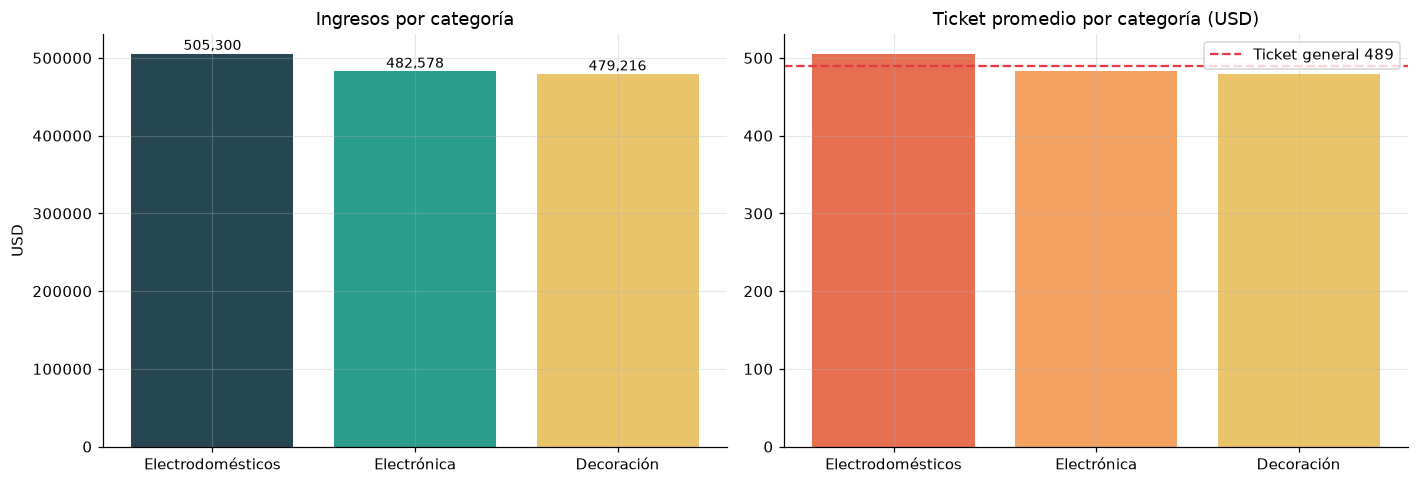

In [25]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

orden = resumen_categoria.index.tolist()
ejes[0].bar(orden, resumen_categoria["ingresos"], color=["#264653", "#2a9d8f", "#e9c46a"])
ejes[0].set_title("Ingresos por categoría")
ejes[0].set_ylabel("USD")
for i, v in enumerate(resumen_categoria["ingresos"]):
    ejes[0].text(i, v * 1.01, f"{v:,.0f}", ha="center", fontsize=9)

ejes[1].bar(orden, resumen_categoria["ticket_promedio"], color=["#e76f51", "#f4a261", "#e9c46a"])
ejes[1].set_title("Ticket promedio por categoría (USD)")
ejes[1].axhline(tabla_ventas["ingreso"].mean(), color="#e63946", linestyle="--",
                label=f"Ticket general {tabla_ventas['ingreso'].mean():,.0f}")
ejes[1].legend()

fig.tight_layout()
fig.savefig("anexos/02_categorias.png")
plt.show()

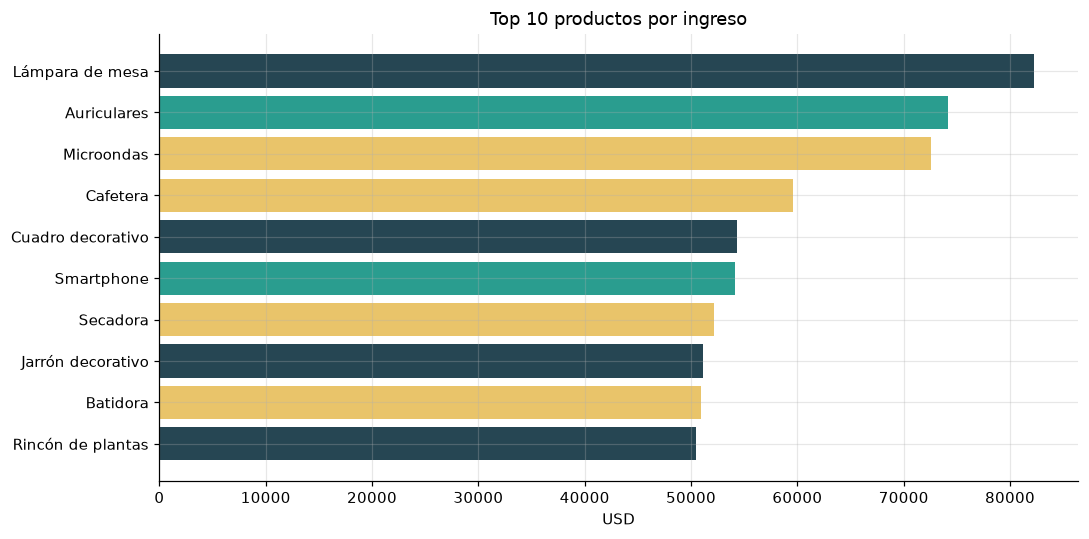

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
top10 = top_categorias.head(10)
colores_cat = {"Decoración": "#264653", "Electrónica": "#2a9d8f", "Electrodomésticos": "#e9c46a"}
ax.barh(top10["producto"][::-1], top10["ingreso"][::-1],
        color=[colores_cat[c] for c in top10["categoria"][::-1]])
ax.set_title("Top 10 productos por ingreso")
ax.set_xlabel("USD")
fig.tight_layout()
fig.savefig("anexos/03_top10_productos.png")
plt.show()

#### Lectura de la agregación

* **Electrodomésticos lidera con USD 505.300 (34,4 %)**, seguido de Electrónica (USD 482.578 / 32,9 %)
  y Decoración (USD 479.216 / 32,7 %). Las tres están **muy parejas**: ninguna concentra el negocio.
* La diferencia **no** viene del volumen de transacciones (1.000 / 998 / 1.000, prácticamente idénticas)
  sino del **ticket promedio**: Electrodomésticos USD 505,30 contra Decoración USD 479,22 (+5,4 %).
* Conclusión: el ingreso se explica por **precio medio, no por frecuencia**. Para crecer, conviene
  subir el ticket en Decoración (packs/accesorios) antes que multiplicar la cantidad de ventas.
* En la ventana de campaña (Etapa 2, Actividad 4) se verá que sólo el **28,4 %** de los ingresos caen
  dentro de un período de campaña activa: hay margen para ampliar la cobertura de marketing.

### Actividad 4 — Integración: unir `ventas` y `marketing`

Se une el comportamiento de venta con las campañas. Primero se muestra **el error típico** y después las dos
formas correctas de hacerlo.

In [27]:
naive = tabla_ventas.merge(marketing, on="producto")
print("❌ CRUCE INMEDIATO SOBRE 'producto'")
print(f"   Filas: {len(tabla_ventas):,} → {len(naive):,}  (×{len(naive)/len(tabla_ventas):.1f})")
print("   Cada venta se repite 3 veces: una por cada canal del producto.\n")

por_canal_naive = naive.groupby("canal")["ingreso"].sum()
print(por_canal_naive.round(2).to_string())
print("\n   Los tres canales muestran EXACTAMENTE los mismos ingresos")
print("   (el total se copió 3 veces) → el análisis carece de sentido.")

❌ CRUCE INMEDIATO SOBRE 'producto'
   Filas: 2,998 → 8,994  (×3.0)
   Cada venta se repite 3 veces: una por cada canal del producto.

canal
Email   1,467,093.52
RRSS    1,467,093.52
TV      1,467,093.52

   Los tres canales muestran EXACTAMENTE los mismos ingresos
   (el total se copió 3 veces) → el análisis carece de sentido.


**Por qué falla:** la relación entre `ventas` y `marketing` es **1‑a‑muchos** (cada producto tiene 3 campañas).
Un `merge` sin agregar multiplica las filas y duplica los ingresos: el costo de campaña se repite 3 veces
por cada venta. Solución: **agregar antes de unir**, o unir por **ventana de tiempo**.

Se aplican las dos formas correctas a continuación.

In [28]:
ventas_por_producto = (
    tabla_ventas.groupby("producto", as_index=False)
    .agg(ingresos=("ingreso", "sum"), unidades=("cantidad", "sum"), transacciones=("id_venta", "count"))
)

marketing["costo"] = marketing["costo"].astype(float)
marketing["inicio"] = pd.to_datetime(marketing["fecha_inicio"], format="%d/%m/%Y")
marketing["fin"] = pd.to_datetime(marketing["fecha_fin"], format="%d/%m/%Y")

marketing_por_producto = (
    marketing.groupby("producto", as_index=False)
    .agg(costo_total=("costo", "sum"), campanas=("id_campanha", "count"))
)

integrado = ventas_por_producto.merge(marketing_por_producto, on="producto")
integrado["roas"] = integrado["ingresos"] / integrado["costo_total"]
integrado = integrado.sort_values("roas", ascending=False)

print("✅ FORMA 1 — AGREGAR Y DESPUÉS UNIR (nivel producto)")
print(f"   Filas: {len(integrado)} (30 productos, sin duplicación)\n")
print(integrado.head(10).round(2).to_string(index=False))
print("\nROAS promedio: {:,.0f} | mediana: {:,.0f} | mín: {:,.0f} | máx: {:,.0f}".format(
    integrado["roas"].mean(), integrado["roas"].median(), integrado["roas"].min(), integrado["roas"].max()))

✅ FORMA 1 — AGREGAR Y DESPUÉS UNIR (nivel producto)
   Filas: 30 (30 productos, sin duplicación)

              producto  ingresos  unidades  transacciones  costo_total  campanas     roas
       Lámpara de mesa 82,276.38      1112            176        15.93         3 5,164.87
            Microondas 72,562.89       912            135        14.19         3 5,113.66
           Auriculares 74,175.58       958            143        15.24         3 4,867.16
              Lavadora 48,946.44       671            100        11.85         3 4,130.50
             Proyector 48,187.00       626             99        12.47         3 3,864.23
     Jarrón decorativo 51,130.88       672            100        13.27         3 3,853.12
    Freidora eléctrica 50,155.15       630            100        13.56         3 3,698.76
Consola de videojuegos 46,174.41       623             99        12.77         3 3,615.85
       Horno eléctrico 49,913.90       633            100        13.89         3 3,593.51
  

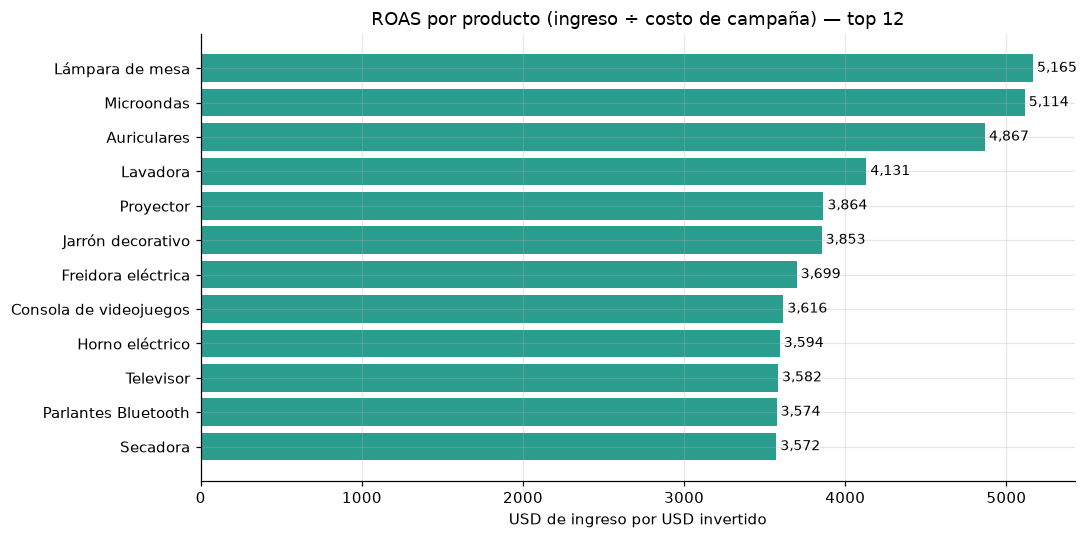

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
top = integrado.head(12)
ax.barh(top["producto"][::-1], top["roas"][::-1], color="#2a9d8f")
ax.set_title("ROAS por producto (ingreso ÷ costo de campaña) — top 12")
ax.set_xlabel("USD de ingreso por USD invertido")
for i, v in enumerate(top["roas"][::-1]):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig("anexos/04_roas_productos.png")
plt.show()

In [30]:
ventas_diarias = tabla_ventas.groupby(["producto", "fecha"], as_index=False)["ingreso"].sum()

campanas = marketing[["id_campanha", "producto", "canal", "costo", "inicio", "fin"]].copy()
campanas["ingresos_en_ventana"] = 0.0
campanas["transacciones_en_ventana"] = 0

for i, c in campanas.iterrows():
    sel = ventas_diarias[(ventas_diarias["producto"] == c["producto"]) &
                         (ventas_diarias["fecha"].between(c["inicio"], c["fin"]))]
    campanas.loc[i, "ingresos_en_ventana"] = sel["ingreso"].sum()
    campanas.loc[i, "transacciones_en_ventana"] = int(
        tabla_ventas[(tabla_ventas["producto"] == c["producto"]) &
                     (tabla_ventas["fecha"].between(c["inicio"], c["fin"]))].shape[0])

campanas["roas"] = campanas["ingresos_en_ventana"] / campanas["costo"]

resumen_canal = (
    campanas.groupby("canal")
    .agg(campanas=("id_campanha", "count"),
         costo=("costo", "sum"),
         ingresos=("ingresos_en_ventana", "sum"),
         transacciones=("transacciones_en_ventana", "sum"))
)
resumen_canal["roas"] = resumen_canal["ingresos"] / resumen_canal["costo"]
resumen_canal["participacion_ingresos_%"] = 100 * resumen_canal["ingresos"] / resumen_canal["ingresos"].sum()

print("✅ FORMA 2 — UNIÓN POR VENTANA TEMPORAL (nivel campaña)")
print("   Sólo se contabiliza la venta si cae dentro de [fecha_inicio, fecha_fin] de la campaña.\n")
print(resumen_canal.round(2).to_string())
print(f"\nCampañas sin ventas en su ventana: "
      f"{int((campanas['transacciones_en_ventana'] == 0).sum())} de {len(campanas)}")
print(f"Ingresos dentro de ventanas de campaña: USD {campanas['ingresos_en_ventana'].sum():,.2f} "
      f"({100 * campanas['ingresos_en_ventana'].sum() / tabla_ventas['ingreso'].sum():.1f}% del total)")

✅ FORMA 2 — UNIÓN POR VENTANA TEMPORAL (nivel campaña)
   Sólo se contabiliza la venta si cae dentro de [fecha_inicio, fecha_fin] de la campaña.

       campanas  costo   ingresos  transacciones     roas  participacion_ingresos_%
canal                                                                              
Email        30 145.20 152,161.04            307 1,047.94                     36.51
RRSS         30 150.91 125,449.52            264   831.29                     30.10
TV           30 147.47 139,197.11            276   943.90                     33.40

Campañas sin ventas en su ventana: 2 de 90
Ingresos dentro de ventanas de campaña: USD 416,807.67 (28.4% del total)


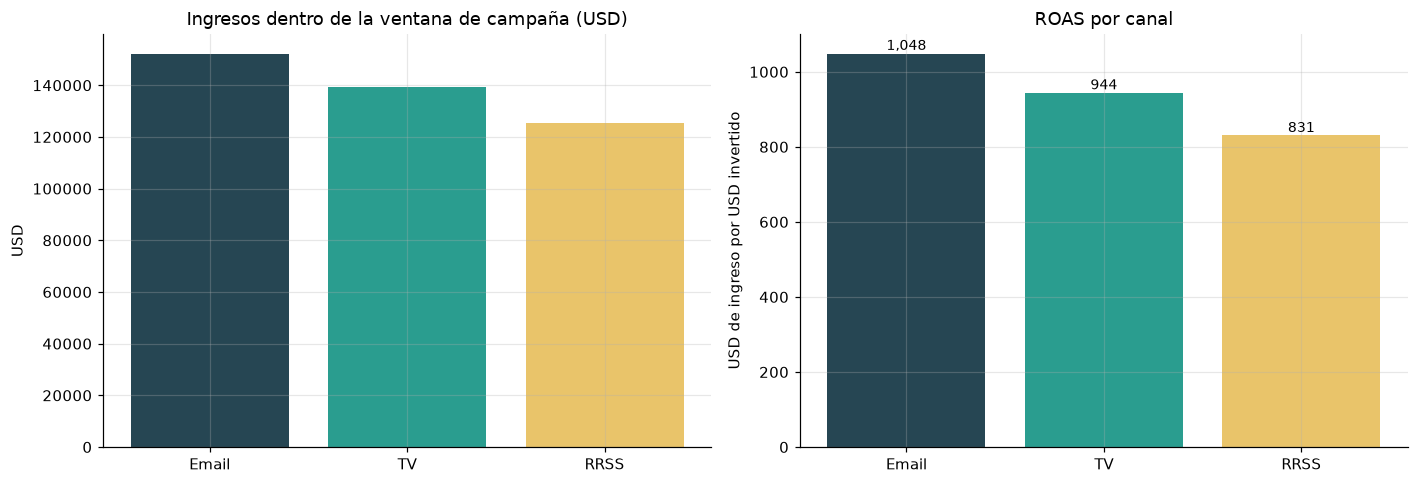

In [31]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
orden_canal = ["Email", "TV", "RRSS"]

ejes[0].bar(orden_canal, resumen_canal.loc[orden_canal, "ingresos"], color=["#264653", "#2a9d8f", "#e9c46a"])
ejes[0].set_title("Ingresos dentro de la ventana de campaña (USD)")
ejes[0].set_ylabel("USD")

ejes[1].bar(orden_canal, resumen_canal.loc[orden_canal, "roas"], color=["#264653", "#2a9d8f", "#e9c46a"])
ejes[1].set_title("ROAS por canal")
ejes[1].set_ylabel("USD de ingreso por USD invertido")
for i, canal in enumerate(orden_canal):
    ejes[1].text(i, resumen_canal.loc[canal, "roas"] * 1.01,
                 f"{resumen_canal.loc[canal, 'roas']:,.0f}", ha="center", fontsize=9)

fig.tight_layout()
fig.savefig("anexos/05_canal_marketing.png")
plt.show()

#### Lectura de la integración

* **ROAS por producto:** promedio 3.322, con **Lámpara de mesa (5.165)** y **Microondas (5.114)** a la cabeza;
  **Candelabro** cierra con 760.
* **Cruce con la Actividad 2:** los productos de alto rendimiento promedian ROAS **4.088** contra
  **3.044** de los demás (+34 %) y **4 de ellos están en el top 10** (Lámpara de mesa, Microondas,
  Auriculares, Jarrón decorativo). El dato de marketing **refuerza la decisión del corte P75**.
* **Por canal:** **Email** obtiene el mejor ROAS (1.048), seguido de **TV** (944) y **RRSS** (831).
  Email gana con el menor costo total (USD 145,2) y el mayor ingreso atribuible (USD 152.161).
* **Cobertura:** sólo el **28,4 %** de los ingresos cae dentro de una ventana de campaña; 2 de 90 campañas
  no tuvieron ventas en su período.

**Limitaciones a declarar**

1. Los datos **no tienen identificador de cliente ni de canal en la venta**: no se puede saber *qué venta*
   vino de *qué campaña*, sólo si ocurrió durante su ventana (atribución temporal, no causal).
2. Cada producto tiene campaña en los 3 canales **al mismo tiempo**, por lo que la comparación entre canales
   es indicativa, no un experimento controlado.
3. Los costos de campaña están en una escala distinta a los ingresos (semanas, no anuales): el ROAS sirve
   para **comparar canales entre sí**, no como retorno absoluto del negocio.

### Análisis de `clientes.csv` — dos enfoques, uno elegido

`clientes.csv` no comparte ninguna columna con `ventas.csv`: **no existe `id_cliente` en las ventas,
ni ciudad ni dato geográfico alguno**. Se evalúan las dos opciones posibles.

In [32]:
print("=" * 70)
print("ENFOQUE A — ANÁLISIS DESCRIPTIVO PROPIO DE clientes.csv")
print("=" * 70)
print(clientes.describe().T.to_string())
print("\nRegistros:", len(clientes), "| nulos:", int(clientes.isna().sum().sum()),
      "| duplicados:", int(clientes.duplicated().sum()))
print("Correlación edad–ingresos:", round(clientes["edad"].corr(clientes["ingresos"]), 4))

ENFOQUE A — ANÁLISIS DESCRIPTIVO PROPIO DE clientes.csv
            count      mean       std    min       25%       50%       75%       max
id_cliente 567.00    284.00    163.82   1.00    142.50    284.00    425.50    567.00
edad       567.00     37.94     10.20  20.00     30.00     37.00     43.00     81.00
ingresos   567.00 34,668.74 12,974.53 170.29 26,015.24 35,066.83 42,457.10 88,053.01

Registros: 567 | nulos: 0 | duplicados: 0
Correlación edad–ingresos: 0.0093


In [33]:
por_ciudad = (
    clientes.groupby("ciudad")
    .agg(clientes=("id_cliente", "count"),
         ingreso_promedio=("ingresos", "mean"),
         ingreso_mediano=("ingresos", "median"),
         edad_promedio=("edad", "mean"))
    .sort_values("ingreso_promedio", ascending=False)
)
print("PERFIL POR CIUDAD")
print(por_ciudad.round(1).to_string())

PERFIL POR CIUDAD
                       clientes  ingreso_promedio  ingreso_mediano  edad_promedio
ciudad                                                                           
Resistencia                  50         36,370.70        35,271.90          41.20
Corrientes                   47         36,244.60        36,725.70          38.20
Santa Fe                     46         35,991.30        35,245.30          38.40
Rosario                      55         35,267.10        35,552.30          40.00
Posadas                      52         35,073.80        35,588.40          36.30
Buenos Aires                 36         34,490.20        36,249.50          36.30
Mar del Plata                63         34,212.70        32,846.20          37.60
Merlo                        43         34,174.00        35,624.50          38.60
Córdoba                      49         34,124.30        35,486.90          35.90
San Miguel de Tucumán        39         33,429.60        30,953.40          37.6

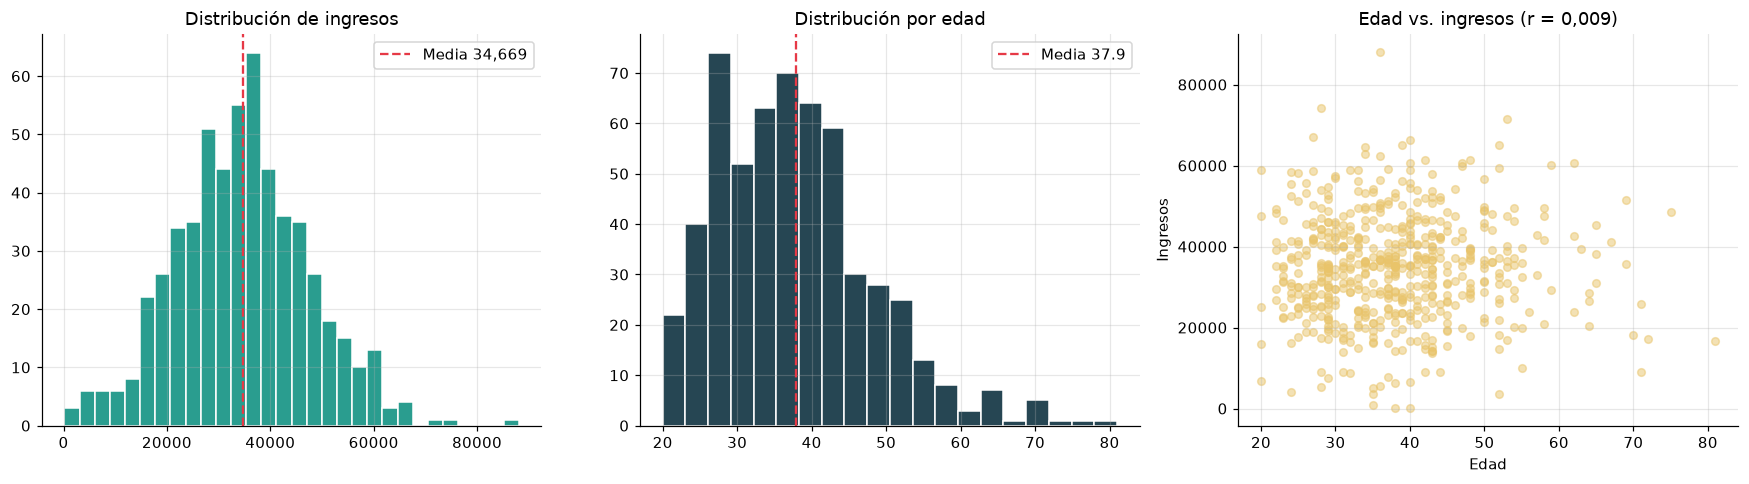

In [34]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.5))

ejes[0].hist(clientes["ingresos"], bins=30, color="#2a9d8f", edgecolor="white")
ejes[0].set_title("Distribución de ingresos")
ejes[0].axvline(clientes["ingresos"].mean(), color="#e63946", linestyle="--",
                label=f"Media {clientes['ingresos'].mean():,.0f}")
ejes[0].legend()

ejes[1].hist(clientes["edad"], bins=20, color="#264653", edgecolor="white")
ejes[1].set_title("Distribución por edad")
ejes[1].axvline(clientes["edad"].mean(), color="#e63946", linestyle="--",
                label=f"Media {clientes['edad'].mean():.1f}")
ejes[1].legend()

ejes[2].scatter(clientes["edad"], clientes["ingresos"], alpha=0.5, color="#e9c46a", s=25)
ejes[2].set_title("Edad vs. ingresos (r = 0,009)")
ejes[2].set_xlabel("Edad")
ejes[2].set_ylabel("Ingresos")

fig.tight_layout()
fig.savefig("anexos/06_clientes.png")
plt.show()

#### Resultado del Enfoque A

567 clientes, 12 ciudades, ingresos medios de USD 34.669 (mediana 35.067, mín. 170, máx. 88.053),
edad promedio 37,9 años (20–81). **La correlación edad–ingresos es 0,009**: no hay relación lineal.
Por ciudad, Resistencia (36.371), Corrientes (36.245) y Santa Fe (35.991) encabezan, pero el rango
entre la mejor y la peor ciudad es de sólo 11 % → **no hay mercados claramente diferenciados**.

In [35]:
print("=" * 70)
print("ENFOQUE B — CRUCE APROXIMADO: asignar cada venta a un cliente al azar")
print("=" * 70)

rng_seeds = [0, 1, 2]
comparacion = {}

for seed in rng_seeds:
    asignacion = pd.DataFrame({
        "ingreso": tabla_ventas["ingreso"].values,
        "id_cliente": np.random.default_rng(seed).choice(clientes["id_cliente"].values,
                                                         size=len(tabla_ventas)),
    })
    por_ciudad_seed = (
        asignacion.merge(clientes, on="id_cliente")
        .groupby("ciudad")["ingreso"].sum()
        .sort_values(ascending=False)
    )
    comparacion[f"seed_{seed}"] = por_ciudad_seed

tabla_seeds = pd.DataFrame(comparacion)
print("Ingreso total por ciudad según la semilla aleatoria (USD)")
print(tabla_seeds.round(0).to_string())

ranks = pd.DataFrame({f"posicion_seed_{sd}": tabla_seeds[f"seed_{sd}"].rank(ascending=False, method="average")
                      for sd in rng_seeds}).astype(int)
ranks["recorrido_posiciones"] = ranks.max(axis=1) - ranks.min(axis=1)
print("\nPosición de cada ciudad según la semilla (1 = mayor ingreso)")
print(ranks.sort_values("recorrido_posiciones", ascending=False).to_string())

ENFOQUE B — CRUCE APROXIMADO: asignar cada venta a un cliente al azar
Ingreso total por ciudad según la semilla aleatoria (USD)
                          seed_0     seed_1     seed_2
ciudad                                                
Bahía Blanca          105,448.00 126,410.00 108,493.00
Buenos Aires           97,755.00  91,268.00 105,503.00
Corrientes            122,112.00 139,427.00 120,988.00
Córdoba               118,675.00 128,175.00 126,579.00
Mar del Plata         169,398.00 149,047.00 160,434.00
Merlo                 108,375.00 103,084.00 110,242.00
Posadas               123,843.00 139,392.00 151,690.00
Resistencia           146,278.00 131,370.00 115,576.00
Rosario               132,900.00 143,565.00 137,019.00
Salta                 121,475.00 107,649.00 108,811.00
San Miguel de Tucumán  93,749.00  87,196.00 104,677.00
Santa Fe              127,086.00 120,510.00 117,081.00

Posición de cada ciudad según la semilla (1 = mayor ingreso)
                       posicion_seed_0  

In [36]:
base_seed = pd.DataFrame({
    "ingreso": tabla_ventas["ingreso"].values,
    "id_cliente": np.random.default_rng(0).choice(clientes["id_cliente"].values, size=len(tabla_ventas)),
}).merge(clientes, on="id_cliente").groupby("ciudad").agg(
    ingreso_asignado=("ingreso", "sum"), clientes=("id_cliente", "count"))

base_seed["%_ingreso"] = 100 * base_seed["ingreso_asignado"] / base_seed["ingreso_asignado"].sum()
base_seed["%_clientes"] = 100 * base_seed["clientes"] / base_seed["clientes"].sum()
base_seed = base_seed.sort_values("%_ingreso", ascending=False)

print("CHEQUEO 1 — ¿el resultado sólo refleja el tamaño de la tabla de clientes?")
print(base_seed[["%_ingreso", "%_clientes"]].round(1).to_string())
print("\nCorrelación(% ingreso asignado, % clientes):",
      round(base_seed["%_ingreso"].corr(base_seed["%_clientes"]), 4))

print("\nCHEQUEO 2 — estabilidad del resultado entre semillas")
cambia = int((ranks["posicion_seed_0"] != ranks["posicion_seed_2"]).sum())
print(f"Ciudades que cambian de puesto entre seed_0 y seed_2: {cambia} de {len(ranks)}")
print("Mayor recorrido:", ranks["recorrido_posiciones"].idxmax(),
      f"({ranks['recorrido_posiciones'].max()} posiciones)")
print("Ganadora por semilla:",
      " | ".join(f"seed_{sd}: {tabla_seeds[f'seed_{sd}'].idxmax()}" for sd in rng_seeds))

print("\nCHEQUEO 3 — columna de unión disponible")
print("Columnas de ventas   :", list(tabla_ventas.columns))
print("Columnas de clientes :", list(clientes.columns))
print("Columnas en común    :", sorted(set(tabla_ventas.columns) & set(clientes.columns)))

CHEQUEO 1 — ¿el resultado sólo refleja el tamaño de la tabla de clientes?
                       %_ingreso  %_clientes
ciudad                                      
Mar del Plata              11.50       11.10
Resistencia                10.00        9.30
Rosario                     9.10        9.50
Santa Fe                    8.70        8.60
Posadas                     8.40        8.70
Corrientes                  8.30        8.20
Salta                       8.30        8.00
Córdoba                     8.10        8.50
Merlo                       7.40        7.40
Bahía Blanca                7.20        7.30
Buenos Aires                6.70        6.60
San Miguel de Tucumán       6.40        6.70

Correlación(% ingreso asignado, % clientes): 0.974

CHEQUEO 2 — estabilidad del resultado entre semillas
Ciudades que cambian de puesto entre seed_0 y seed_2: 7 de 12
Mayor recorrido: Resistencia (5 posiciones)
Ganadora por semilla: seed_0: Mar del Plata | seed_1: Mar del Plata | seed_2: Mar de

#### Decisión: **se adopta el Enfoque A (análisis descriptivo propio); el cruce aproximado se descarta**

| | Enfoque A — descriptivo | Enfoque B — cruce aleatorio |
|---|---|---|
| ¿Tiene clave de unión? | No hace falta: analiza su propio dataset | **No existe ninguna** (`columnas en común: []`) |
| ¿Los números son verificables? | Sí, se reproducen con `clientes.csv` | No: dependen de un número aleatorio |
| ¿Es estable? | Sí, idéntico en cada ejecución | **No**: 7 de 12 ciudades cambian de puesto entre una semilla y otra (Resistencia pasa del 2.º al 7.º lugar) |
| ¿Qué mide? | La realidad de la tabla de clientes | El tamaño de la propia tabla de clientes (correlación **0,974** entre % ingreso asignado y % clientes) |

**Por qué se descarta el cruce B.** No hay forma de saber qué cliente hizo cada compra: ni `id_cliente`,
ni ciudad, ni segmento. Cualquier unión tendría que **inventar** esa relación. Se lo probó igual y los
resultados lo delatan: (1) el "ingreso por ciudad" no es más que el *número de clientes por ciudad*
proporcionalmente repartido — corr = 0,974 entre ambas participaciones —, es decir, mide la tabla que
nosotros fabricamos y no la de ventas; (2) el ranking se mueve al cambiar la semilla (7 de 12 ciudades
cambian de puesto, con hasta 5 posiciones de recorrido) y la ciudad "ganadora" resulta siempre la de más
clientes (Mar del Plata, 63), con lo que **no es reproducible** ni aporta información de ventas;
(3) el chequeo de columnas en común devuelve la lista vacía, confirmando que no existe llave.

Por eso, sin forzar una unión imposible, `clientes.csv` se usa como **análisis descriptivo complementario**
(Enfoque A): aporta el perfil demográfico del negocio y queda asentado, además, que **para poder cruzar
haría falta registrar el `id_cliente` en cada venta**, una mejora de captura de datos que se recomienda.

## Conclusiones generales

**Etapa 1**
1. Los tres CSV se cargaron correctamente como DataFrames y se identificaron sus formatos crudos.
2. El script en Python puro (sin pandas) calculó los totales mensuales: 12 meses de 2024,
   máximo en abril (USD 144.380) y mínimo en junio (USD 108.480). Su total crudo (USD 1.483.042,93)
   supera en **USD 15.949,41** al limpio: así se mide el costo de no depurar los duplicados.
3. Se eligió el **diccionario indexado por `id_venta`** para almacenar ventas por acceso O(1) y unicidad de claves.
4. El EDA mostró 30 productos / 3 categorías balanceadas, 90 campañas (30 × 3 canales) y 567 clientes.
5. Calidad inicial: **35 duplicados + 2 nulos** en `ventas.csv`; los otros dos datasets, limpios.

**Etapa 2**
1. Limpieza: 3.035 → **2.998 filas**, `precio` a numérico, fechas a tipo real, `ingreso` como métrica base.
2. Filtro de alto rendimiento con criterio **P75 (USD 51.093)**: **8 productos, 34,1 % de los ingresos**.
3. Agregación: categorías muy parejas; la diferencia de ingreso la explica el **ticket promedio**, no el volumen.
4. Integración: se evitó la trampa del `merge` 1‑a‑muchos (que triplicaba las filas); con agregación
   previa, **ROAS medio 3.322** (los 8 productos de alto rendimiento promedian 4.088);
   por ventana temporal, **Email (1.048) > TV (944) > RRSS (831)** y sólo 28,4 % de los ingresos
   están cubiertos por campañas.
5. `clientes.csv`: se probaron ambos enfoques y se adoptó el **descriptivo**, porque no existe clave de
   unión con ventas y el cruce aleatorio no es ni verificable ni reproducible.

**Recomendación de negocio:** priorizar los 8 productos de alto rendimiento en Email (mejor ROAS),
elevar el ticket promedio en Decoración y registrar `id_cliente` en ventas para habilitar análisis
de comportamiento por cliente en futuros cortes.

## 📎 Anexo

Bloque con descripción y enlaces a todos los archivos adicionales incluidos en la carpeta de entrega
(`Franco Oscar Alejandro - Comisión C26251 - TPI Data Analytics`).

| # | Archivo | Descripción | Link en Drive |
|---|---|---|---|
| 1 | `TP_Integrador.ipynb` | Este notebook (Etapas 1 y 2) | _completar con el enlace del notebook en Drive_ |
| 2 | `datos/ventas.csv` | Dataset original de ventas (sin modificar) | _completar con el enlace_ |
| 3 | `datos/clientes.csv` | Dataset original de clientes (sin modificar) | _completar con el enlace_ |
| 4 | `datos/marketing.csv` | Dataset original de marketing (sin modificar) | _completar con el enlace_ |
| 5 | `anexos/01_alto_rendimiento.png` | Gráfico: corte de alto rendimiento por producto (P75) | _completar con el enlace_ |
| 6 | `anexos/02_categorias.png` | Gráfico: ingresos y ticket promedio por categoría | _completar con el enlace_ |
| 7 | `anexos/03_top10_productos.png` | Gráfico: top 10 productos por ingreso | _completar con el enlace_ |
| 8 | `anexos/04_roas_productos.png` | Gráfico: ROAS por producto | _completar con el enlace_ |
| 9 | `anexos/05_canal_marketing.png` | Gráfico: ingresos y ROAS por canal | _completar con el enlace_ |
| 10 | `anexos/06_clientes.png` | Gráfico: distribución de clientes (ingresos, edad) | _completar con el enlace_ |
| 11 | `README.md` | Instrucciones de uso del repositorio | _completar con el enlace_ |
| 12 | `Pre.docx` | Consigna del trabajo práctico | _completar con el enlace_ |

> Los links se completan una vez que la carpeta está en Google Drive: clic derecho sobre el archivo →
> **Compartir → Copiar enlace** (acceso: cualquiera con el enlace).

In [37]:
print("ARCHIVOS GENERADOS POR ESTE NOTEBOOK")
raiz = Path(".")
for ruta in sorted(raiz.rglob("*")):
    if ruta.is_file() and ".ipynb_checkpoints" not in str(ruta) and ruta.suffix in {".png", ".csv", ".md", ".ipynb", ".docx"}:
        print(f"  {ruta}  ({ruta.stat().st_size:,} bytes)")
print("\nCopia la carpeta 'anexos/' a Google Drive y completa los links de la tabla del Anexo.")

ARCHIVOS GENERADOS POR ESTE NOTEBOOK
  Pre.docx  (17,290 bytes)
  TP_Integrador.ipynb  (62,760 bytes)
  anexos/01_alto_rendimiento.png  (93,821 bytes)
  anexos/02_categorias.png  (42,106 bytes)
  anexos/03_top10_productos.png  (35,668 bytes)
  anexos/04_roas_productos.png  (55,015 bytes)
  anexos/05_canal_marketing.png  (39,351 bytes)
  anexos/06_clientes.png  (103,511 bytes)
  datos/clientes.csv  (24,220 bytes)
  datos/marketing.csv  (4,456 bytes)
  datos/ventas.csv  (165,693 bytes)
  ~$Pre.docx  (162 bytes)

Copia la carpeta 'anexos/' a Google Drive y completa los links de la tabla del Anexo.
